Importing all the modules

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

Loading in the training and testing datasets

In [2]:

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 174kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.15MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.0MB/s]


Creating the neural layers and forward

In [3]:
class mod(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.h1 = nn.Linear(784, 16)
        self.relu = nn.ReLU()
        self.lbh1 = nn.Linear(16, 8)
        self.lbh2 = nn.Linear(8, 8)

        self.branch2 = nn.Sequential(
            nn.Linear(16,12),
            nn.ReLU(),
            nn.Linear(12,8),
            nn.ReLU()
        )
        self.out = nn.Linear(16,10)
    def forward(self, x):
        x = self.flatten(x)
        x = self.h1(x)
        x_first = self.lbh1(x)
        x_first = self.relu(x_first)
        x_final = self.lbh2(x_first)
        x_final = self.relu(x_final)
        x2 = self.branch2(x)
        x1 = x_final+x_first
        com = torch.cat((x1, x2), dim=1)
        output = self.out(com)
        return output

model = mod()

defining the learning rate, batch size and epochs

In [4]:
lr = 0.0001
batch_size = 64
epochs = 5


defining the training loop

In [5]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0  # Initialize total loss for the epoch
    for batch, (X, y) in enumerate(dataloader):
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()  # Accumulate loss
        if batch % 100 == 0:
            current_loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {current_loss:>7f}  [{current:>5d}/{size:>5d}]")
    avg_train_loss = total_loss / len(dataloader)  # Calculate average loss
    return avg_train_loss  # Return average training loss

Defining the testing loop

In [6]:
def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, correct  # Return test loss and accuracy

Training the neural network and running it against the test dataset

In [7]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
epochs = 10

train_losses = []
test_losses = []
test_accuracies = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    avg_train_loss = train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_accuracy = test_loop(test_dataloader, model, loss_fn)

    train_losses.append(avg_train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

print("Done!")

Epoch 1
-------------------------------
loss: 2.331635  [   64/60000]
loss: 2.133497  [ 6464/60000]
loss: 1.859959  [12864/60000]
loss: 1.643090  [19264/60000]
loss: 1.506220  [25664/60000]
loss: 1.291611  [32064/60000]
loss: 1.174984  [38464/60000]
loss: 1.069054  [44864/60000]
loss: 1.006911  [51264/60000]
loss: 0.914189  [57664/60000]
Test Error: 
 Accuracy: 67.8%, Avg loss: 0.916811 

Epoch 2
-------------------------------
loss: 0.996476  [   64/60000]
loss: 0.971753  [ 6464/60000]
loss: 0.739251  [12864/60000]
loss: 0.898992  [19264/60000]
loss: 0.854195  [25664/60000]
loss: 0.787251  [32064/60000]
loss: 0.805571  [38464/60000]
loss: 0.814587  [44864/60000]
loss: 0.776093  [51264/60000]
loss: 0.717815  [57664/60000]
Test Error: 
 Accuracy: 74.6%, Avg loss: 0.732155 

Epoch 3
-------------------------------
loss: 0.733928  [   64/60000]
loss: 0.783810  [ 6464/60000]
loss: 0.563310  [12864/60000]
loss: 0.773978  [19264/60000]
loss: 0.757839  [25664/60000]
loss: 0.662897  [32064/600

Plotting the accuracy and loss graphs

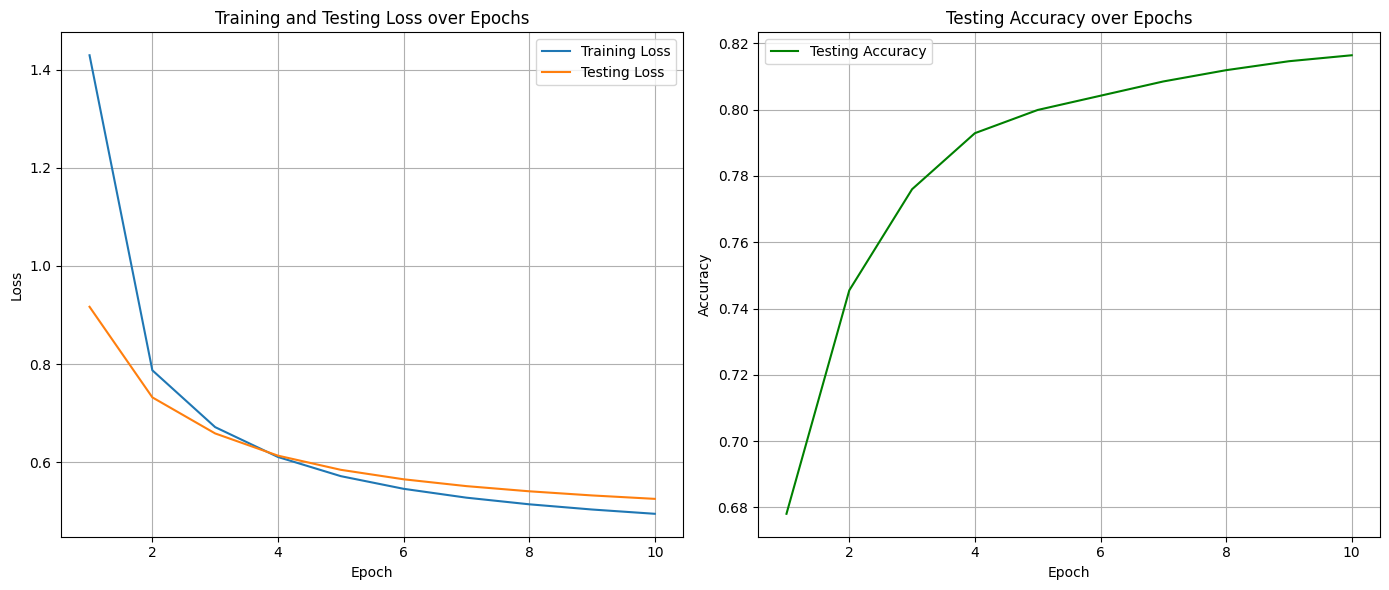

In [8]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plotting training and testing loss on the first subplot
ax1.plot(range(1, epochs + 1), train_losses, label='Training Loss')
ax1.plot(range(1, epochs + 1), test_losses, label='Testing Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Testing Loss over Epochs')
ax1.legend()
ax1.grid(True)

# Plotting testing accuracy on the second subplot
ax2.plot(range(1, epochs + 1), test_accuracies, label='Testing Accuracy', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Testing Accuracy over Epochs')
ax2.legend()
ax2.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

Saving the model weights and the test results

In [9]:
import os
output_dir = 'model_outputs'
os.makedirs(output_dir, exist_ok=True)
model_path = os.path.join(output_dir, 'model_weights.pth')
torch.save(model.state_dict(), model_path)
print(f"Model weights saved to {model_path}")

Model weights saved to model_outputs/model_weights.pth


In [10]:
import pandas as pd
predictions = []
true_labels = []
model.eval()
with torch.no_grad():
    for X, y in test_dataloader:
        outputs = model(X)
        _, predicted = torch.max(outputs.data, 1)
        predictions.extend(predicted.cpu().numpy())
        true_labels.extend(y.cpu().numpy())
results_df = pd.DataFrame({
    'True Label': true_labels,
    'Predicted Label': predictions
})
predictions_path = os.path.join(output_dir, 'test_predictions.csv')
results_df.to_csv(predictions_path, index=False)
print(f"Test predictions saved to {predictions_path}")

display(results_df.head())

Test predictions saved to model_outputs/test_predictions.csv


,True Label,Predicted Label
0,9,9
1,2,2
2,1,1
3,1,1
4,6,6
